In [2]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned monthly data
df = pd.read_csv("../data/processed/epiclim_dengue_monthly_cleaned.csv")

df.head()


,state_ut,district,year_month,Latitude,Longitude,Cases,Deaths,preci,LAI,Temp,Cases_MA_3,Deaths_MA_3,Case_Growth_Rate,Month,Season
0,Andaman and Nicobar Islands,Andaman,2019-06,13.511120,92.917388,8.0,0.0,0.772605,33.0,301.720000,8.0,0.0,0.000000,6,Monsoon
1,Andaman and Nicobar Islands,Andaman,2019-10,13.511120,92.917388,30.0,0.0,0.149858,42.0,298.906667,19.0,0.0,2.750000,10,Post-Monsoon
2,Andaman and Nicobar Islands,North and Middle Andaman,2013-12,12.611239,92.831654,86.0,0.0,0.188149,53.0,298.200000,86.0,0.0,0.000000,12,Winter
3,Andhra Pradesh,Anantapur,2010-06,14.654623,77.556260,68.0,0.0,0.254048,0.0,311.175000,68.0,0.0,0.000000,6,Monsoon
4,Andhra Pradesh,Anantapur,2011-06,14.654623,77.556260,232382.0,0.0,0.027715,0.0,307.820000,116225.0,0.0,3416.382353,6,Monsoon


In [4]:
df[['Cases', 'Deaths', 'preci', 'Temp', 'LAI']].describe()


,Cases,Deaths,preci,Temp,LAI
count,6.709000e+03,6709.000000,6709.000000,6709.000000,6709.000000
mean,1.775473e+40,0.603220,0.424014,275.662326,8.321205
std,1.454257e+42,5.482364,0.591274,85.609498,8.213217
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.700000e+01,0.000000,0.014567,299.276000,2.500000
50%,3.600000e+01,0.000000,0.184327,302.723333,6.500000
75%,1.870000e+02,0.000000,0.629814,308.190000,12.000000
max,1.191160e+44,252.000000,5.680000,327.728000,62.000000


In [7]:
print("Unique districts:", df['district'].nunique())
print("Date range:", df['year_month'].min(), "to", df['year_month'].max())


Unique districts: 791
Date range: 2009-05 to 2022-06


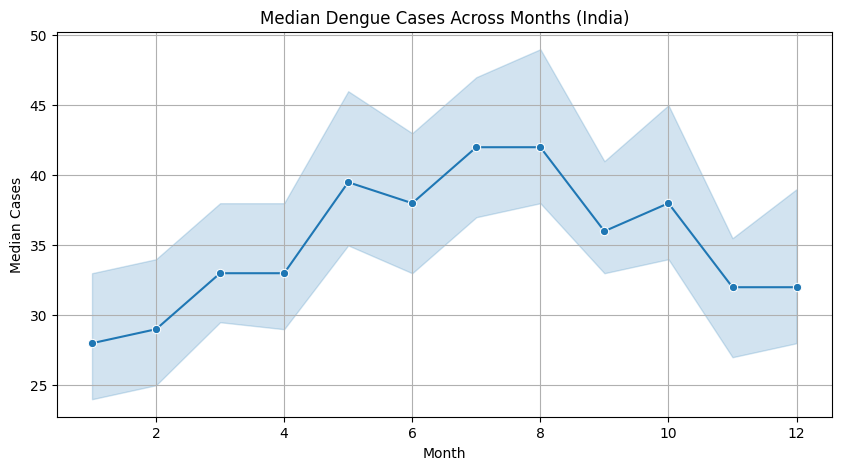

In [17]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df,
    x='Month',
    y='Cases',
    estimator='median',
    marker='o'
)
plt.title("Median Dengue Cases Across Months (India)")
plt.xlabel("Month")
plt.ylabel("Median Cases")
plt.grid(True)
plt.show()


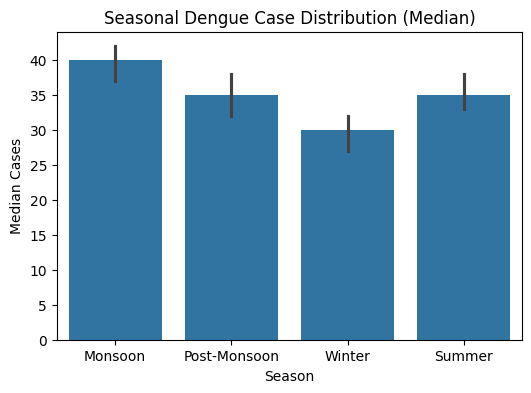

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Season', y='Cases', estimator='median')
plt.title("Seasonal Dengue Case Distribution (Median)")
plt.xlabel("Season")
plt.ylabel("Median Cases")
plt.show()


In [13]:
top_districts = (
    df.groupby('district')['Cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_districts


district
New Delhi            1.191160e+44
East Siang           4.736910e+38
Bankura              2.112317e+31
Seppa Town           2.449678e+21
South 24 Parganas    5.944286e+19
North 24 Parganas    5.224774e+19
Hooghly              4.571676e+18
Muzaffarpur          1.291291e+17
Kottayam             7.101433e+16
West Siang           1.529345e+16
Name: Cases, dtype: float64

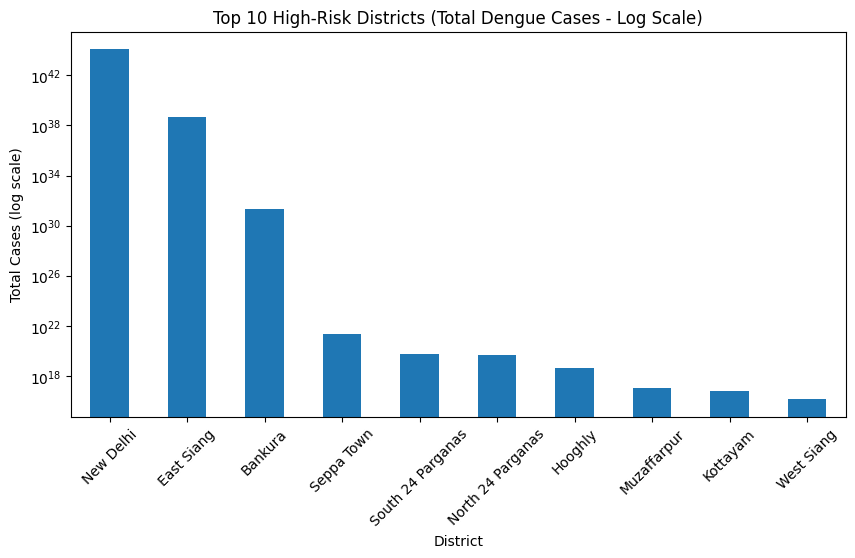

In [18]:
plt.figure(figsize=(10,5))
top_districts.plot(kind='bar')
plt.yscale('log')
plt.title("Top 10 High-Risk Districts (Total Dengue Cases - Log Scale)")
plt.xlabel("District")
plt.ylabel("Total Cases (log scale)")
plt.xticks(rotation=45)
plt.show()


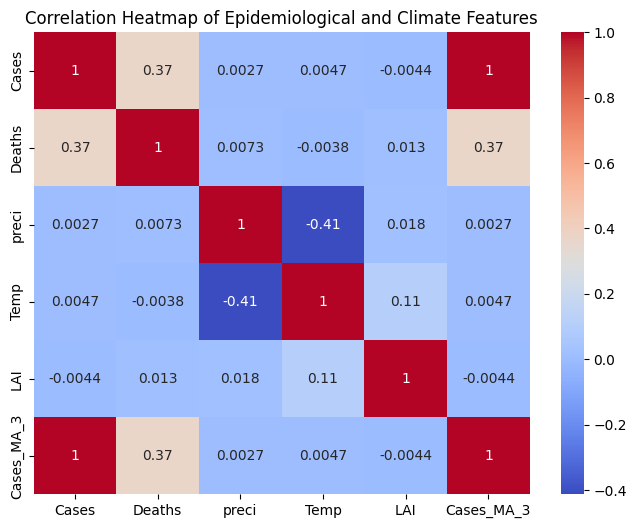

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Cases', 'Deaths', 'preci', 'Temp', 'LAI', 'Cases_MA_3']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap of Epidemiological and Climate Features")
plt.show()
